# Init package

In [1]:
%cd /home/FullMouth/code
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import time
import torch
from pathlib import Path
from glob import glob
import shutil
import math
from datasets import load_dataset, Dataset
from peft import LoraConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.device_count() , torch.cuda.get_device_name(0)

/home/FullMouth/code


(1, 'NVIDIA H100 80GB HBM3')

### Load dataset

In [2]:
# instruct_4_n20/Qwen2.5-7B-Instruct_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep05r16_medium_3instructs09 done
# instruct_4_n20/Qwen2.5-14B-Instruct_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep04r16_medium_3instructs09 done
# Llama-3.1-8B-Instruct_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep05r16_medium_3instructs09 done
# OLMo-2-1124-7B-DPO_revisedTrain_withDesc_withEx_withErrFeed_ep04r16_medium done
# gemma-2-9b-it_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep07r16_medium_3instructs09 done
# OLMo-2-1124-13B-DPO_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep05r16_medium_3instructs09 done
# granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep07r16_medium_3instructs09 
model_name = 'granite-3.1-8b-instruct'
ep='07'
r=16
# module_lv = 'light'
module_lv = 'medium'

In [3]:
num_of_instructions = 3
validation_threshold = 0.9
version = f'4_n20'
prompt_selected = '3instructs09'

model_type ='revisedTrain_withDesc_withEx_withErrFeed'

model_name = f'{model_name}_{model_type}'
model_settings = f'ep{ep}r{r}_{module_lv}'

model_root = os.path.join(r'/data_sys/lang_model/', version)
load_model_dir = os.path.join(model_root, f'{model_name}_{model_settings}')

root_dir = r'/home/FullMouth/data'

target_model_dir = os.path.join(root_dir, f'instruct_{version}', model_name, )

print(load_model_dir)
print(target_model_dir)

/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium
/home/FullMouth/data/instruct_4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed


In [5]:
data_root = os.path.join(target_model_dir, f'DPO_data_{model_settings}_{prompt_selected}')
print(data_root)
jsonl_fp_train = os.path.join(data_root, 'dpo_data_train.jsonl')
jsonl_fp_val = os.path.join(data_root, 'dpo_data_val.jsonl')

train_dataset = load_dataset("json", data_files=jsonl_fp_train, split='train')
val_dataset = load_dataset("json", data_files=jsonl_fp_val, split='train')

print(train_dataset)
print(val_dataset)

/home/FullMouth/data/instruct_4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed/DPO_data_ep07r16_medium_3instructs09
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4065
})
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 1045
})


# Load Lora

In [6]:
# LoRA config based on QLoRA paper

if module_lv == 'light':
        model_ls = ["q_proj", "v_proj"]
elif module_lv == 'medium':
        model_ls = ["q_proj", "k_proj", "v_proj", "o_proj"]
elif module_lv == 'full':
        model_ls = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]


peft_config = LoraConfig(
        r=r, lora_alpha=int(2*r),
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM", 
        target_modules = model_ls,
)


# Load models and config

In [7]:
use_flash_attention = True

In [8]:
model_output_dir = load_model_dir + '_DPO'
if os.path.exists(model_output_dir): shutil.rmtree(model_output_dir); print('delete old model dir')
if not os.path.exists(model_output_dir):
    Path(model_output_dir).mkdir(parents=True, exist_ok=True)
print(load_model_dir)
print(model_output_dir)

delete old model dir
/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium
/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO


In [9]:
# Load model and tokenizer
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    load_model_dir,
    quantization_config=bnb_config,
    attn_implementation="flash_attention_2",
    device_map="auto",
)
# model.config.pretraining_tp = 1 # for llama

from peft import prepare_model_for_kbit_training
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False  # Required for gradient checkpointing

tokenizer = AutoTokenizer.from_pretrained(load_model_dir, legacy=False)
tokenizer.padding_side = "right"

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

In [10]:
from trl import DPOConfig, DPOTrainer

In [11]:
world_size = torch.cuda.device_count()
per_device_batch_size = 2
grad_accum = 8  # keep effective batch size similar

effective_batch_size = per_device_batch_size * grad_accum * world_size
steps_per_epoch = math.ceil(len(train_dataset) / effective_batch_size)
half_epoch_steps = steps_per_epoch // 2

logging_steps = half_epoch_steps // 2
save_eval_steps = half_epoch_steps
steps_per_epoch, save_eval_steps, logging_steps

(255, 127, 63)

In [12]:
training_args = DPOConfig(
    do_train=True,
    do_eval=True,
    eval_strategy="steps",
    beta=0.1,
    learning_rate=5e-5,
    num_train_epochs=2,
    per_device_train_batch_size=per_device_batch_size,  # Reduce
    per_device_eval_batch_size=per_device_batch_size,
    gradient_accumulation_steps=grad_accum,  # Should be 8 to match calculations

    gradient_checkpointing=True,  # Enable
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Fix for quantized models
    bf16=True,
    eval_steps=save_eval_steps,
    logging_steps=logging_steps,
    output_dir=model_output_dir,
    save_steps=save_eval_steps,
)

In [13]:
if not hasattr(model, "warnings_issued"):
    model.warnings_issued = {}

# if model is a PeftModel, also patch the base model to be safe
if hasattr(model, "base_model") and not hasattr(model.base_model, "warnings_issued"):
    model.base_model.warnings_issued = {}
if hasattr(model, "base_model") and hasattr(model.base_model, "model") and not hasattr(model.base_model.model, "warnings_issued"):
    model.base_model.model.warnings_issued = {}

In [14]:
trainer = DPOTrainer(model=model, 
                     peft_config=peft_config,
                    #  ref_model=None,
                     args=training_args, 
                     processing_class=tokenizer,
                     train_dataset=train_dataset,
                     eval_dataset=val_dataset,)

In [15]:
# Recalculate steps based on actual packed dataloader length
actual_steps_per_epoch = math.ceil(len(trainer.get_train_dataloader()) / grad_accum)
save_eval_steps = max(1, actual_steps_per_epoch // 8)
logging_steps = max(1, actual_steps_per_epoch // 16)

trainer.args.eval_steps = save_eval_steps
trainer.args.save_steps = save_eval_steps
trainer.args.logging_steps = logging_steps

print(f"Packed steps/epoch: {actual_steps_per_epoch}, eval/save every {save_eval_steps} steps, log every {logging_steps} steps")

Packed steps/epoch: 255, eval/save every 31 steps, log every 15 steps


In [16]:
import time
import sys
sys.path.append(r'/home/tg_bot')
from tg_bot_send import send_msg_https

In [17]:
start_time = time.time()
trainer.train()
end_time = time.time()
send_msg_https(f'DPO training done for {model_output_dir}! - Time taken: {(end_time - start_time)/60:.1f} minutes')

Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
31,0.238147,0.178376,0.755187,-1.923427,0.958891,2.678615,-16.892731,-49.223625,-3.050236,-2.762797
62,0.239751,0.160335,0.282114,-2.388319,0.958891,2.670434,-21.623459,-53.872547,-3.912472,-3.178787
93,0.211720,0.158378,1.154499,-2.003625,0.958891,3.158124,-12.899615,-50.025604,-1.733822,-2.253412
124,0.224128,0.157847,0.502906,-2.547048,0.958891,3.049955,-19.415541,-55.459839,-2.626598,-2.471999
155,0.146465,0.155354,1.181278,-2.001594,0.958891,3.182872,-12.631825,-50.005287,-1.538308,-1.865990
186,0.161357,0.152835,0.916338,-2.332727,0.958891,3.249064,-15.281222,-53.316624,-1.802827,-1.944683
217,0.156372,0.155214,0.650516,-2.776030,0.958891,3.426546,-17.939438,-57.749653,-1.810276,-2.028879
248,0.169726,0.154894,-0.503494,-3.600082,0.960803,3.096588,-29.479542,-65.990173,-2.235590,-2.449587
279,0.113265,0.154577,-2.716348,-6.598865,0.958891,3.882517,-51.608078,-95.977997,-3.386626,-3.235296
310,0.128598,0.143340,-2.620777,-6.308171,0.961759,3.687395,-50.652367,-93.071075,-3.591643,-3.323776


200

# Find best checkpoint

In [ ]:
import pandas as pd

In [ ]:
tmp = ['loss', 'eval_loss', 'rewards/accuracies', 'eval_rewards/chosen',  'eval_logps/rejected', 'eval_logits/chosen', 'logps/rejected', 'train_steps_per_second', 'train_runtime', 'grad_norm', 'train_samples_per_second', 'total_flos', 'eval_runtime', 'logits/rejected', 'logps/chosen', 'eval_samples_per_second', 'eval_rewards/margins', 'eval_logits/rejected', 'eval_rewards/accuracies', 'rewards/rejected', 'learning_rate', 'eval_rewards/rejected', 'rewards/margins', 'train_loss', 'rewards/chosen', 'logits/chosen', 'eval_logps/chosen']
tmp.sort()
tmp

In [20]:
logs = trainer.state.log_history
num_step_per_epoch = logs[-1]['step'] / logs[-1]['epoch']
print(num_step_per_epoch)

# Collect all unique keys from logs (excluding 'step' and 'epoch')
all_keys = set()
for log in logs:
    all_keys.update(log.keys())
all_keys -= {'step', 'epoch'}

# Initialize dictionaries to store values and steps for each metric
metrics = {key: {'values': [], 'steps': []} for key in all_keys}

for log in logs:
    steps = log['step'] # / num_step_per_epoch
    for key in all_keys:
        if key in log:
            metrics[key]['values'].append(log[key])
            metrics[key]['steps'].append(steps)

# Print summary of collected metrics
for key in sorted(metrics.keys()):
    print(f"{key}: {len(metrics[key]['values'])} entries")

255.0
eval_logits/chosen: 16 entries
eval_logits/rejected: 16 entries
eval_logps/chosen: 16 entries
eval_logps/rejected: 16 entries
eval_loss: 16 entries
eval_rewards/accuracies: 16 entries
eval_rewards/chosen: 16 entries
eval_rewards/margins: 16 entries
eval_rewards/rejected: 16 entries
eval_runtime: 16 entries
eval_samples_per_second: 16 entries
eval_steps_per_second: 16 entries
grad_norm: 34 entries
learning_rate: 34 entries
logits/chosen: 34 entries
logits/rejected: 34 entries
logps/chosen: 34 entries
logps/rejected: 34 entries
loss: 34 entries
rewards/accuracies: 34 entries
rewards/chosen: 34 entries
rewards/margins: 34 entries
rewards/rejected: 34 entries
total_flos: 1 entries
train_loss: 1 entries
train_runtime: 1 entries
train_samples_per_second: 1 entries
train_steps_per_second: 1 entries


In [ ]:

key_ls = [
# 'train_loss',
 'eval_loss',
'eval_logits/chosen', 'eval_logits/rejected',
#'eval_logps/chosen','eval_logps/rejected',
'eval_rewards/accuracies', 'eval_rewards/chosen', 'eval_rewards/margins', 'eval_rewards/rejected',

]
# key_ls = [
# 'logits/chosen', 'logits/rejected', 'logps/chosen', 'logps/rejected',
# 'rewards/accuracies', 'rewards/chosen', 'rewards/margins', 'rewards/rejected',
# ]

In [ ]:
df_ls = []
for key_name in key_ls:#metrics.keys():
    
    df = pd.DataFrame(metrics[key_name])
    df['steps'] = df['steps'].astype(int)
    df = df.set_index('steps').rename(columns={'values': key_name})
    df_ls.append(df)


In [ ]:
df_final = pd.concat(df_ls, axis=1)
df_final = df_final.reset_index().sort_values('steps')

In [ ]:
# print the row where step could be divided by 26
df_final[df_final['steps'] % 26 == 0]

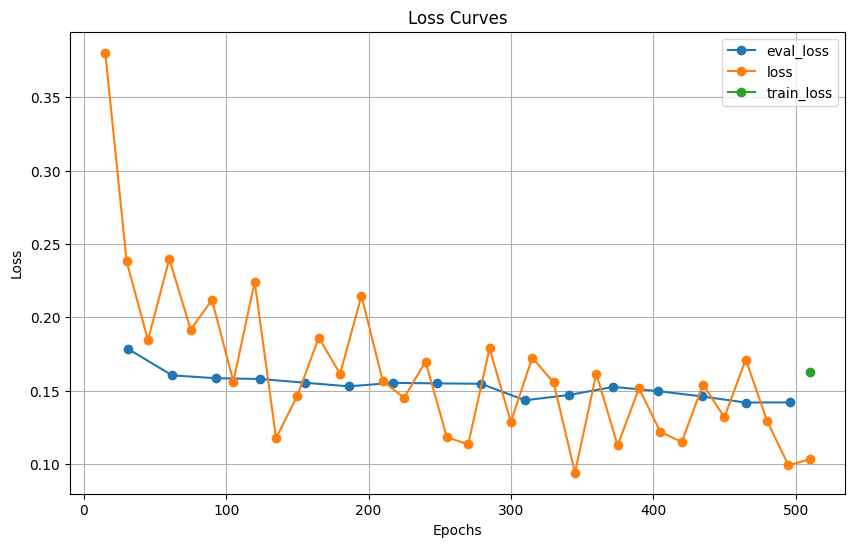

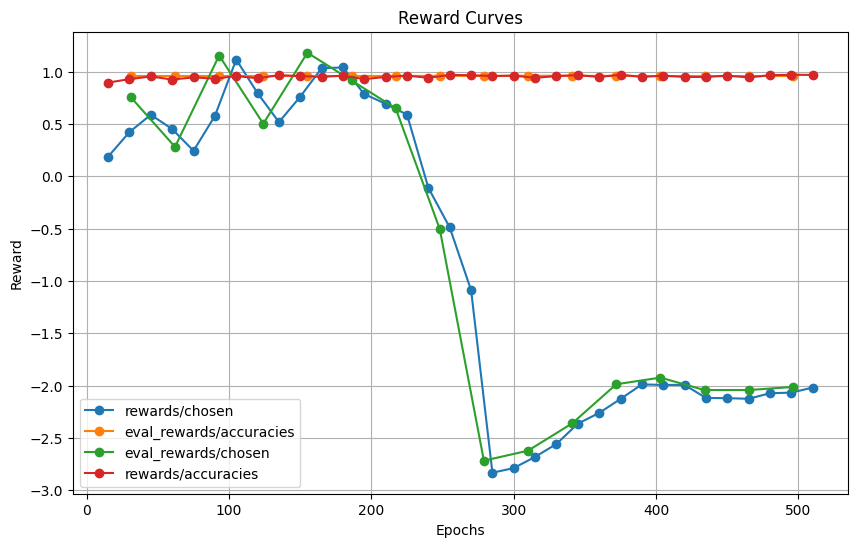

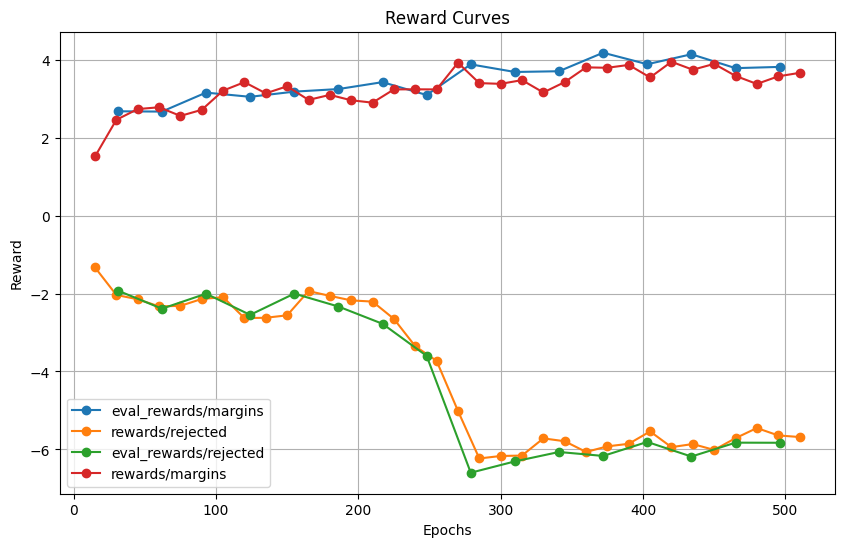

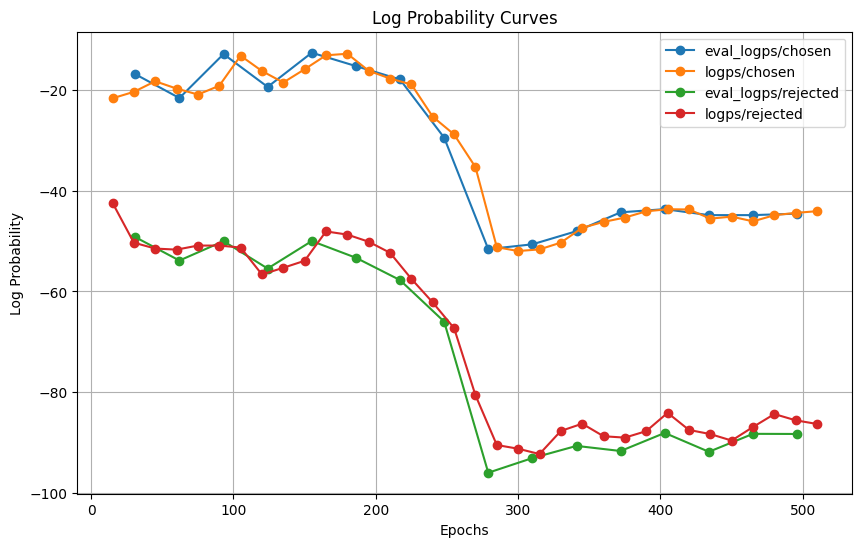

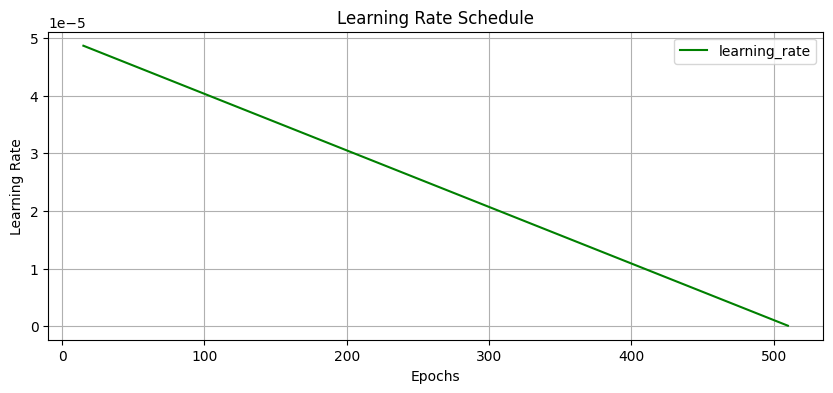

In [21]:
import matplotlib.pyplot as plt

# Define which metrics to plot together
loss_metrics = [k for k in metrics.keys() if 'loss' in k.lower()]
reward_metrics = [k for k in metrics.keys() if 'reward' in k.lower()]
logps_metrics = [k for k in metrics.keys() if 'logps' in k.lower() or 'logprob' in k.lower()]
other_metrics = [k for k in metrics.keys() if k not in loss_metrics + reward_metrics + logps_metrics 
                 and k not in ['learning_rate', 'train_runtime', 'train_samples_per_second', 
                              'train_steps_per_second', 'total_flos', 'train_loss']]

# Plot losses
if loss_metrics:
    plt.figure(figsize=(10, 6))
    for key in loss_metrics:
        if metrics[key]['values']:
            plt.plot(metrics[key]['steps'], metrics[key]['values'], label=key, marker='o' if len(metrics[key]['values']) < 50 else None)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot rewards
if reward_metrics:
    for key_ls in [['rewards/chosen', 'eval_rewards/accuracies', 'eval_rewards/chosen', 'rewards/accuracies', ],
    ['eval_rewards/margins', 'rewards/rejected', 'eval_rewards/rejected', 'rewards/margins', ]]:

        plt.figure(figsize=(10, 6))
        for key in key_ls:
            if metrics[key]['values']:
                plt.plot(metrics[key]['steps'], metrics[key]['values'], label=key, marker='o' if len(metrics[key]['values']) < 50 else None)
        plt.xlabel('Epochs')
        plt.ylabel('Reward')
        plt.title('Reward Curves')
        plt.legend()
        plt.grid(True)
        plt.show()

# Plot log probabilities
if logps_metrics:
    plt.figure(figsize=(10, 6))
    for key in logps_metrics:
        if metrics[key]['values']:
            plt.plot(metrics[key]['steps'], metrics[key]['values'], label=key, marker='o' if len(metrics[key]['values']) < 50 else None)
    plt.xlabel('Epochs')
    plt.ylabel('Log Probability')
    plt.title('Log Probability Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot learning rate if available
if 'learning_rate' in metrics and metrics['learning_rate']['values']:
    plt.figure(figsize=(10, 4))
    plt.plot(metrics['learning_rate']['steps'], metrics['learning_rate']['values'], label='learning_rate', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.legend()
    plt.grid(True)
    plt.show()

# Save the model

In [22]:
step_epoch_dict = {l['step']: float(l['epoch']) for l in logs[:]}
for fn in os.listdir(model_output_dir):
    if fn.startswith('checkpoint-'):
        check_num = int(fn.replace('checkpoint-', ''))
        print(f'{fn:<15s} - {step_epoch_dict[check_num]:.1f}')

checkpoint-31   - 0.1
checkpoint-62   - 0.2
checkpoint-93   - 0.4
checkpoint-124  - 0.5
checkpoint-155  - 0.6
checkpoint-186  - 0.7
checkpoint-217  - 0.9
checkpoint-248  - 1.0
checkpoint-279  - 1.1
checkpoint-310  - 1.2
checkpoint-341  - 1.3
checkpoint-372  - 1.5
checkpoint-403  - 1.6
checkpoint-434  - 1.7
checkpoint-465  - 1.8
checkpoint-496  - 1.9
checkpoint-510  - 2.0


In [23]:
step_num = 155
ep = f'{step_epoch_dict[step_num]:.1f}'.replace('.', '')
load_model_dir = os.path.join(model_output_dir, f'checkpoint-{step_num}')
output_model_name = f'{os.path.basename(model_output_dir)}_ep{ep}'
save_dir = os.path.join('/data_sys/lang_model', version, output_model_name)
print(load_model_dir)
print(save_dir)

/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO/checkpoint-155
/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO_ep06


In [24]:
if os.path.exists(save_dir): shutil.rmtree(save_dir); print('delete old model dir')

In [25]:
from peft import AutoPeftModelForCausalLM

In [26]:
model = AutoPeftModelForCausalLM.from_pretrained(
    load_model_dir,
    low_cpu_mem_usage=True,
) 
tokenizer = AutoTokenizer.from_pretrained(load_model_dir, legacy=False)
tokenizer.padding_side = "right"

# Merge LoRA and base model
merged_model = model.merge_and_unload()

merged_model.save_pretrained(save_dir, safe_serialization=True)
tokenizer.save_pretrained(save_dir)

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO_ep06/tokenizer_config.json',
 '/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO_ep06/chat_template.jinja',
 '/data_sys/lang_model/4_n20/granite-3.1-8b-instruct_revisedTrain_withDesc_withEx_withErrFeed_ep07r16_medium_DPO_ep06/tokenizer.json')

In [28]:
for fn in os.listdir(model_output_dir):
    if fn.startswith('checkpoint-'):
        shutil.rmtree(os.path.join(model_output_dir, fn))